# AT3 — Chuva forte em Curitiba (R10mm)

Continuação do `atv2_arvore`: regressão só nos dias com chuva ≥ 10 mm. Decisões, achados e referências na última célula.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
pd.set_option("display.width", 140)

In [2]:
# No Colab, descomente para montar o Drive:
# from google.colab import drive
#
# drive.mount('/content/drive')

In [3]:
from pathlib import Path

PASTA = Path("../../commons/data")
# No Colab, use o caminho do Drive:
# PASTA = Path("/content/drive/MyDrive")

df = pd.read_parquet(PASTA / "curitiba_daily.parquet").sort_values("date").reset_index(drop=True)

# synoptic.py e subdaily.py já deslocam para t-1: o join é sem shift
EXTRAS = []
for nome in ["curitiba_synoptic.parquet", "curitiba_subdaily.parquet"]:
    extra = pd.read_parquet(PASTA / nome)
    df = df.join(extra, on="date")
    EXTRAS += list(extra.columns)

# todos os conjuntos avaliados nas mesmas linhas
df = df.dropna(subset=EXTRAS).reset_index(drop=True)
df.head()

,date,tp_mm,ssrd_wm2,t2m,t2m_min,t2m_max,d2m,dpd,wind_speed,wind_const,...,wind850_const,wind850_dir_sin,wind850_dir_cos,msl_tend,tcwv_tend,cape_tend,cape_max_lag3,tcwv_mean_lag3,wind_max,d2m_range
0,1980-04-01,0.365138,164.091782,16.377014,13.584625,19.219391,13.565399,2.811615,3.557601,0.994403,...,0.995480,0.867004,-0.498302,304.640625,-11.784046,-145.500,326.500,32.290985,4.239836,2.695099
1,1980-04-02,0.120771,179.277222,16.698456,13.498688,21.525055,13.814331,2.884125,2.316316,0.986427,...,0.964308,0.996868,-0.079082,-58.671875,-0.589602,-0.500,165.625,31.707979,3.681856,2.690460
2,1980-04-03,1.311496,195.243958,17.726776,14.785553,22.519684,14.285675,3.441101,1.947963,0.971664,...,0.901211,0.984846,0.173429,-131.968750,1.961582,-4.000,20.125,19.923933,2.749712,3.302399
3,1980-04-04,6.795540,148.697220,18.550293,15.958160,22.249176,16.062836,2.487457,1.714343,0.953920,...,0.983075,0.742985,0.669308,-87.796875,4.041027,-7.500,19.625,19.334332,2.709458,1.601349
4,1980-04-05,2.635221,144.128891,19.203552,17.001373,23.068512,17.138489,2.065063,1.144617,0.389403,...,0.197587,0.530985,-0.847381,-167.140625,10.413525,298.625,15.625,21.295914,1.956160,1.401917


In [4]:
FIGDIR = Path("figuras")
FIGDIR.mkdir(exist_ok=True)

def salvar(nome, fig=None, dpi=200, fechar=False):
    """Salva a figura atual em PNG. Chame ANTES de plt.show()."""
    fig = fig or plt.gcf()
    fig.savefig(FIGDIR / f"{nome}.png", dpi=dpi,
                bbox_inches="tight", facecolor="white")
    print(f"salvo: {nome}.png")
    if fechar:
        plt.close(fig)

## Limiar: R10mm

In [5]:
LIMIAR = 10.0          # R10mm do ETCCDI
ANO_CORTE = 2014       # dev <= 2014, teste >= 2015

df["ano"] = df.date.dt.year
df["mes"] = df.date.dt.month
df["doy"] = df.date.dt.dayofyear
df["forte"] = df.tp_mm >= LIMIAR

n_anos = (df.date.max() - df.date.min()).days / 365.25
chuvoso = df.tp_mm >= 1    # base do percentil no ETCCDI

print(pd.DataFrame({"todos os dias": df.tp_mm.quantile([.5, .9, .95, .99]),
                    "dias chuvosos": df.tp_mm[chuvoso].quantile([.5, .9, .95, .99])}).round(2))
print(f"\ndias chuvosos: {int(chuvoso.sum())} ({100 * chuvoso.mean():.0f}%)")

      todos os dias  dias chuvosos
0.50           0.94           5.33
0.90          12.88          18.94
0.95          18.81          25.70
0.99          36.04          46.58

dias chuvosos: 8195 (49%)


In [6]:
cands = {"R1mm": 1.0, "5 mm": 5.0, "R10mm": LIMIAR, "R20mm": 20.0,
         "p99 chuvosos": float(df.tp_mm[chuvoso].quantile(.99)), "50 mm": 50.0}

limiares = pd.DataFrame([
    {"critério": nome, "limiar_mm": round(u, 1), "n_dias": int((df.tp_mm >= u).sum()),
     "pct_dias": 100 * (df.tp_mm >= u).mean(), "por_ano": (df.tp_mm >= u).sum() / n_anos,
     "n_dev": int((df.tp_mm >= u)[df.ano <= ANO_CORTE].sum()),
     "n_teste": int((df.tp_mm >= u)[df.ano > ANO_CORTE].sum()),
     "pct_da_chuva": 100 * float(df.tp_mm[df.tp_mm >= u].sum() / df.tp_mm.sum())}
    for nome, u in cands.items()])
print(limiares.round(1).to_string(index=False))

    critério  limiar_mm  n_dias  pct_dias  por_ano  n_dev  n_teste  pct_da_chuva
        R1mm        1.0    8195      49.0    179.1   6265     1930          97.3
        5 mm        5.0    4258      25.5     93.1   3275      983          83.6
       R10mm       10.0    2395      14.3     52.4   1857      538          64.6
       R20mm       20.0     722       4.3     15.8    572      150          31.9
p99 chuvosos       46.6      82       0.5      1.8     67       15           7.0
       50 mm       50.0      62       0.4      1.4     50       12           5.7


salvo: limiar.png


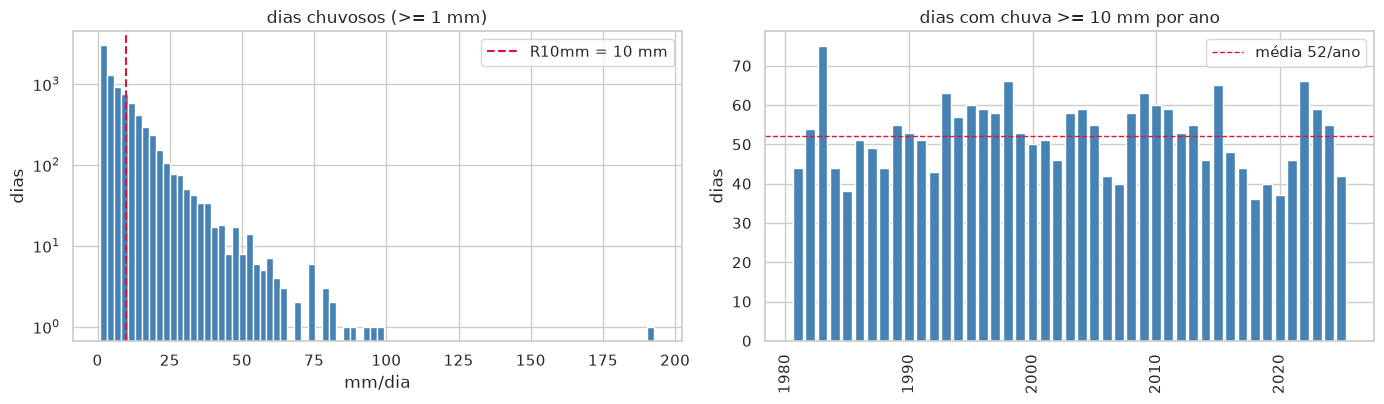

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].hist(df.tp_mm[chuvoso], bins=80, color="steelblue")
axes[0].axvline(LIMIAR, color="crimson", ls="--", lw=1.5, label=f"R10mm = {LIMIAR:g} mm")
axes[0].set(title="dias chuvosos (>= 1 mm)", xlabel="mm/dia", ylabel="dias", yscale="log")
axes[0].legend()

completos = df.groupby("ano").size() > 360
por_ano = df[df.ano.isin(completos[completos].index)].groupby("ano").forte.sum()
axes[1].bar(por_ano.index, por_ano.values, color="steelblue")
axes[1].axhline(por_ano.mean(), color="crimson", ls="--", lw=1, label=f"média {por_ano.mean():.0f}/ano")
axes[1].set(title=f"dias com chuva >= {LIMIAR:g} mm por ano", xlabel="", ylabel="dias")
axes[1].tick_params(axis="x", rotation=90)
axes[1].legend()

plt.tight_layout()
salvar("limiar")
plt.show()

## Faixas disjuntas

`tp_sum7/30/90` são aninhados; as faixas cobrem os mesmos 90 dias sem sobreposição (mesma operação de `bands.py`).

In [8]:
ANINHADAS = ["tp_sum7", "tp_sum30", "tp_sum90"]
FAIXAS    = ["tp_d1_7", "tp_d8_30", "tp_d31_90"]

df["tp_d1_7"]   = df.tp_sum7                   # t-7  a t-1
df["tp_d8_30"]  = df.tp_sum30 - df.tp_sum7     # t-30 a t-8
df["tp_d31_90"] = df.tp_sum90 - df.tp_sum30    # t-90 a t-31

assert np.allclose(df[FAIXAS].sum(axis=1), df.tp_sum90, atol=1e-3)
assert (df[FAIXAS] >= -1e-6).all().all()

comp = pd.DataFrame({
    "corr_alvo_aninhada": [df.tp_mm.corr(df[c], method="spearman") for c in ANINHADAS],
    "corr_alvo_faixa":    [df.tp_mm.corr(df[c], method="spearman") for c in FAIXAS],
    "autocorr_lag1":      [df[c].autocorr(1) for c in FAIXAS],
}, index=["7 dias", "8-30 dias", "31-90 dias"])
print(comp.round(3))

            corr_alvo_aninhada  corr_alvo_faixa  autocorr_lag1
7 dias                   0.306            0.306          0.920
8-30 dias                0.300            0.240          0.983
31-90 dias               0.259            0.158          0.995


salvo: faixas_correlacao.png


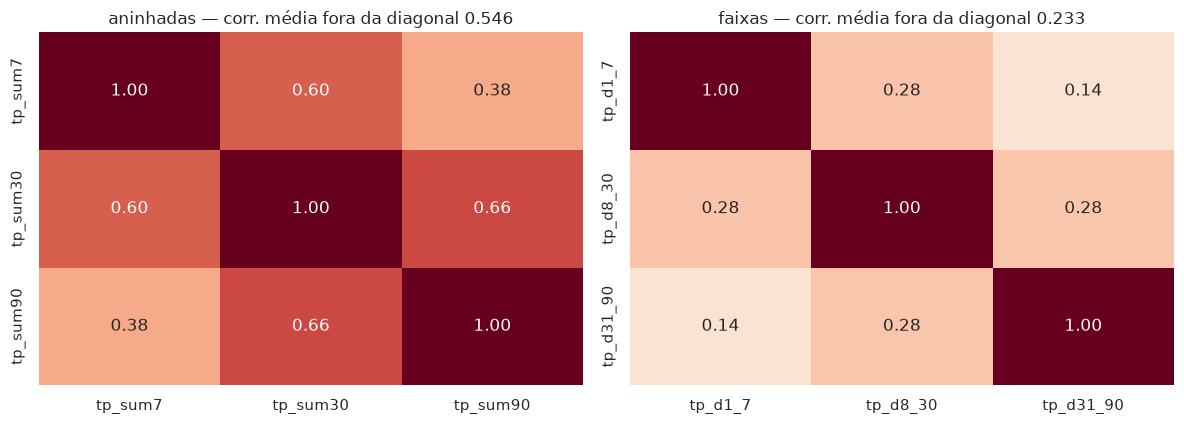

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, cols, titulo in zip(axes, [ANINHADAS, FAIXAS], ["aninhadas", "faixas"]):
    c = df[cols].corr("spearman")
    sns.heatmap(c, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, cbar=False)
    fora = c.values[np.triu_indices(3, 1)]
    ax.set(title=f"{titulo} — corr. média fora da diagonal {fora.mean():.3f}")
plt.tight_layout()
salvar("faixas_correlacao")
plt.show()

## Subamostra de dias fortes

In [10]:
sub = df[df.forte].reset_index(drop=True)

print(f"dias fortes: {len(sub)} ({100 * df.forte.mean():.1f}% da série, {len(sub) / n_anos:.0f}/ano)")
print(f"dev: {int((sub.ano <= ANO_CORTE).sum())} | teste: {int((sub.ano > ANO_CORTE).sum())}")
print(f"alvo: média {sub.tp_mm.mean():.1f} | mediana {sub.tp_mm.median():.1f} | "
      f"máx {sub.tp_mm.max():.1f} | std {sub.tp_mm.std():.2f} mm")

saz = pd.DataFrame({"dias_fortes": sub.mes.value_counts().sort_index(),
                    "dias_totais": df.mes.value_counts().sort_index()})
saz["pct_do_mes_forte"]  = 100 * saz.dias_fortes / saz.dias_totais
saz["pct_da_subamostra"] = 100 * saz.dias_fortes / len(sub)
saz["intensidade_media"] = sub.groupby("mes").tp_mm.mean()
print("\n", saz.round(1))

dias fortes: 2395 (14.3% da série, 52/ano)
dev: 1857 | teste: 538
alvo: média 19.2 | mediana 15.7 | máx 192.7 | std 11.34 mm

      dias_fortes  dias_totais  pct_do_mes_forte  pct_da_subamostra  intensidade_media
mes                                                                                  
1            363         1395              26.0               15.2          18.100000
2            289         1271              22.7               12.1          17.600000
3            195         1395              14.0                8.1          15.800000
4            102         1380               7.4                4.3          19.700001
5            147         1426              10.3                6.1          21.799999
6            147         1380              10.7                6.1          21.700001
7            124         1426               8.7                5.2          24.100000
8            125         1426               8.8                5.2          21.700001
9            

salvo: sazonalidade.png


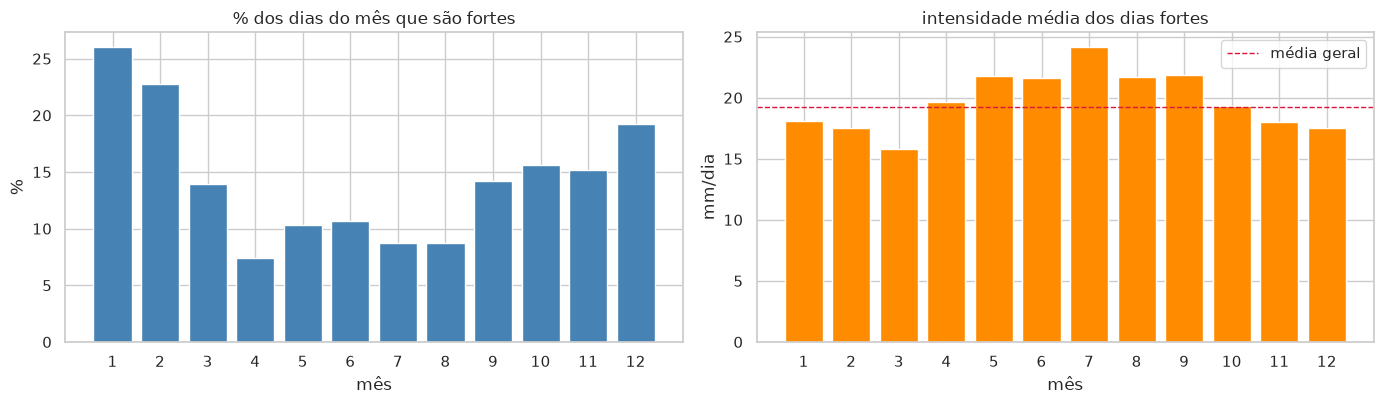

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].bar(saz.index, saz.pct_do_mes_forte, color="steelblue")
axes[0].set(title="% dos dias do mês que são fortes", xlabel="mês", ylabel="%")
axes[0].set_xticks(range(1, 13))

axes[1].bar(saz.index, saz.intensidade_media, color="darkorange")
axes[1].axhline(sub.tp_mm.mean(), color="crimson", ls="--", lw=1, label="média geral")
axes[1].set(title="intensidade média dos dias fortes", xlabel="mês", ylabel="mm/dia")
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.tight_layout()
salvar("sazonalidade")
plt.show()

## Dependência temporal

In [12]:
ac = pd.DataFrame({
    "forte (série)":      {k: df.forte.astype(float).autocorr(k) for k in (1, 2, 3, 7, 30)},
    "tp_mm (subamostra)": {k: sub.tp_mm.autocorr(k) for k in (1, 2, 3)},
})
ac.index.name = "lag"
print(ac.round(3))

     forte (série)  tp_mm (subamostra)
lag                                   
1            0.218               0.065
2            0.055               0.052
3            0.026               0.023
7            0.037                 NaN
30           0.008                 NaN


In [13]:
# índice extremal θ pelo método de runs (r = 1): dias contíguos formam um episódio
bloco = (df.forte != df.forte.shift()).cumsum()
runs = df[df.forte].groupby(bloco[df.forte]).agg(
    n=("tp_mm", "size"), ini=("date", "first"), fim=("date", "last"), total=("tp_mm", "sum"))
theta = len(runs) / df.forte.sum()
maior = runs.loc[runs.n.idxmax()]

print(f"episódios: {len(runs)} | duração média: {runs.n.mean():.2f} dias | θ = {theta:.3f}")
print(f"maior: {maior.n} dias, {maior.ini:%Y-%m-%d} a {maior.fim:%Y-%m-%d}, {maior.total:.0f} mm")
print(runs.n.value_counts().sort_index().rename("episódios").to_string())

episódios: 1605 | duração média: 1.49 dias | θ = 0.670
maior: 7 dias, 1990-01-06 a 1990-01-12, 179 mm
n
1    1062
2     375
3     109
4      46
5       9
6       1
7       3


## Divisão temporal

Folds por data, não por linha: na subamostra, `test_size=365*4` seriam ~27 anos. Mesma `date_folds` de `evaluation.py`.

In [14]:
def date_folds(dates, n_splits=5, val_years=4, end=None):
    """Folds de janela expansiva sobre blocos de calendário, como um splitter do sklearn."""
    dates = pd.to_datetime(pd.Series(dates)).reset_index(drop=True)
    end = dates.max().normalize() + pd.Timedelta(days=1) if end is None else pd.Timestamp(end)
    bordas = [end - pd.DateOffset(years=val_years * k) for k in range(n_splits + 1)][::-1]
    folds = []
    for ini, fim in zip(bordas[:-1], bordas[1:]):
        tr = np.where(dates < ini)[0]
        va = np.where((dates >= ini) & (dates < fim))[0]
        if len(tr) and len(va):
            folds.append((tr, va))
    return folds

dev   = sub[sub.ano <= ANO_CORTE].reset_index(drop=True)
teste = sub[sub.ano >  ANO_CORTE].reset_index(drop=True)   # tocado uma única vez, no fim
y_te  = teste.tp_mm
folds = date_folds(dev.date, n_splits=5, val_years=4, end=f"{ANO_CORTE + 1}-01-01")

periodos = pd.DataFrame([
    {"fold": k, "treino_até": dev.date[tr[-1]].date(), "n_treino": len(tr),
     "val_ini": dev.date[va[0]].date(), "val_fim": dev.date[va[-1]].date(), "n_val": len(va)}
    for k, (tr, va) in enumerate(folds, 1)])
print(periodos.to_string(index=False))

 fold treino_até  n_treino    val_ini    val_fim  n_val
    1 1994-12-31       766 1995-01-02 1998-12-29    243
    2 1998-12-29      1009 1999-01-01 2002-12-25    200
    3 2002-12-25      1209 2003-01-04 2006-12-24    214
    4 2006-12-24      1423 2007-01-04 2010-12-26    221
    5 2010-12-26      1644 2011-01-07 2014-12-26    213


## Baselines e métrica

O alvo é o **p90** da chuva do dia forte, não a média. A métrica é a perda pinball no quantil 0,9: um dia que passa da previsão
custa 0,9 por mm, um dia que fica abaixo custa 0,1 por mm. O mínimo dela é o p90 verdadeiro, assim como o mínimo do erro quadrático é a média.

Três números por modelo:

- **pinball** (mm, menor é melhor): é o que seleciona o modelo
- **skill contra a climatologia** (`1 - pinball_modelo / pinball_clim`): o ganho em % sobre o p90 de cada mês
- **cobertura** (fração dos dias abaixo da previsão): um p90 calibrado fica perto de 0,90. Abaixo disso o modelo erra para baixo,
  acima disso ele está largo demais

In [15]:
from sklearn.metrics import mean_pinball_loss

Q = 0.90    # quantil previsto

def pin(y, p):
    """Perda pinball no quantil Q: errar para baixo custa Q por mm, para cima 1 - Q."""
    return mean_pinball_loss(y, p, alpha=Q)

def cobertura(y, p):
    """Fração dos dias que ficaram abaixo da previsão; um p90 calibrado dá 0,90."""
    return float(np.mean(np.asarray(y) <= np.asarray(p)))

def baselines(treino, alvo_df):
    """p90 climatológico refeito sobre a subamostra, ajustado só no treino."""
    clim = treino.groupby(treino.date.dt.month).tp_mm.quantile(Q)
    geral = treino.tp_mm.quantile(Q)
    return {
        "climatologia mensal p90": alvo_df.date.dt.month.map(clim).fillna(geral).to_numpy(),
        "p90 constante (dev)":     np.full(len(alvo_df), geral),
    }

base = pd.DataFrame([{"baseline": k, "pinball": pin(y_te, v), "cobertura": cobertura(y_te, v)}
                     for k, v in baselines(dev, teste).items()]).set_index("baseline")
print(base.sort_values("pinball").round(3))
print(f"\np90 observado no teste: {y_te.quantile(Q):.2f} mm")

                         pinball  cobertura
baseline                                   
p90 constante (dev)        2.486      0.896
climatologia mensal p90    2.486      0.911

p90 observado no teste: 32.51 mm


## Features

40 → 29 por redundância (`|Spearman| > 0,85` entre features, cego ao alvo); 29 → 20 sem as 9 que nenhuma árvore usa (célula de uso abaixo).

In [16]:
MET   = ["ssrd_wm2", "t2m", "d2m", "dpd", "wind_speed", "wind_const"]
CICLO = ["wind_dir_sin", "wind_dir_cos", "day_sin", "day_cos"]

# importância zero em todos os folds (profundidade 4, folha 50), medida na célula de uso por fold
IMPORTANCIA_ZERO = ["cape_max", "cape_max_lag3", "cape_tend", "d2m_range", "msl_min",
                "tcwv_mean_lag3", "tp_lag2", "wind850_const", "wind_speed"]

SEM_REDUNDANCIA = (MET + CICLO + ["tp_lag1", "tp_lag2", "tp_lag3"]
          + ["dpd_lag2", "d2m_lag2", "dpd_lag3"]
          + ["cape_max", "tcwv_mean", "msl_min", "msl_tend", "tcwv_tend", "cape_tend",
             "wind850_speed_mean", "wind850_const", "wind850_dir_sin", "wind850_dir_cos",
             "cape_max_lag3", "tcwv_mean_lag3", "d2m_range"])

CONJUNTOS = {
    "vespera":      MET + CICLO + ["tp_lag1"],                         # 11, referência atv2
    "so_atmosfera": MET + CICLO,                                       # 10
    "vespera+850":  MET + CICLO + ["tp_lag1", "wind850_speed_mean"],   # 12
    "sem_redundancia": [c for c in SEM_REDUNDANCIA if c not in IMPORTANCIA_ZERO],  # 20
}
for k, v in CONJUNTOS.items():
    print(f"{k:14s} {len(v):2d} features")

vespera        11 features
so_atmosfera   10 features
vespera+850    12 features
sem_redundancia 20 features


In [17]:
# descritiva, só no dev — não foi ela que escolheu as features
TODAS = sorted({c for v in CONJUNTOS.values() for c in v})
df_dev, sub_dev = df[df.ano <= ANO_CORTE], sub[sub.ano <= ANO_CORTE]

sinal = pd.DataFrame({
    "serie_toda":  [df_dev.tp_mm.corr(df_dev[c], method="spearman") for c in TODAS],
    "dias_fortes": [sub_dev.tp_mm.corr(sub_dev[c], method="spearman") for c in TODAS],
}, index=TODAS)
print(sinal.sort_values("dias_fortes", key=abs, ascending=False).round(3))

                    serie_toda  dias_fortes
wind850_speed_mean       0.093        0.212
ssrd_wm2                -0.050       -0.177
day_cos                  0.370       -0.167
wind_speed               0.046        0.158
d2m_lag2                 0.390       -0.119
wind_dir_cos             0.141        0.118
t2m                      0.373       -0.116
d2m                      0.486       -0.113
tcwv_tend                0.287        0.113
wind850_dir_sin          0.000       -0.097
day_sin                  0.059       -0.095
tp_lag3                  0.191       -0.090
wind850_dir_cos          0.159        0.080
wind_dir_sin            -0.019       -0.074
wind_const              -0.048        0.069
tp_lag1                  0.536        0.068
msl_tend                -0.108       -0.065
dpd                     -0.327       -0.046
tcwv_mean                0.576       -0.030
dpd_lag3                -0.047        0.029
dpd_lag2                -0.129       -0.004


## Machine Learning

#### Configurações

In [18]:
from itertools import product
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor   # só na célula de uso, que definiu IMPORTANCIA_ZERO

SEED = 42

# árvores rasas, taxa baixa e subamostragem: o p90 de uma árvore só oscila demais entre folhas.
# O número de árvores é fixado pela grade; early stopping tiraria validação de dentro do treino de cada fold
GRADE = [{"max_depth": d, "n_estimators": n, "min_samples_leaf": f,
          "learning_rate": 0.05, "subsample": 0.8}
         for d, n, f in product([1, 2, 3], [25, 50, 100, 200, 400], [20, 50])]

def modelo(**hp):
    return GradientBoostingRegressor(loss="quantile", alpha=Q, random_state=SEED, **hp)

print(f"{len(CONJUNTOS)} conjuntos × {len(GRADE)} hiperparâmetros = "
      f"{len(CONJUNTOS) * len(GRADE)} modelos")

4 conjuntos × 30 hiperparâmetros = 120 modelos


#### Uso das features por fold

In [19]:
uso = pd.DataFrame(0, index=SEM_REDUNDANCIA, columns=[f"fold{i+1}" for i in range(len(folds))])
for i, (i_tr, _) in enumerate(folds):
    m = DecisionTreeRegressor(random_state=SEED, criterion="poisson", max_depth=4,
                              min_samples_leaf=50).fit(dev.iloc[i_tr][SEM_REDUNDANCIA], dev.iloc[i_tr].tp_mm)
    uso.iloc[:, i] = (m.feature_importances_ > 0).astype(int)
uso["n_folds"] = uso.sum(axis=1)

print("nunca usadas:", sorted(uso[uso.n_folds == 0].index))
print("usadas em >= 4 folds:", sorted(uso[uso.n_folds >= 4].index))

nunca usadas: ['cape_max', 'cape_max_lag3', 'cape_tend', 'd2m_range', 'msl_min', 'tcwv_mean_lag3', 'tp_lag2', 'wind850_const', 'wind_speed']
usadas em >= 4 folds: ['day_cos', 'tp_lag1', 'wind850_speed_mean']


#### Ajuste de Hiperparâmetros

In [20]:
def rotulo(cj, hp):
    return f"{cj} | d={hp['max_depth']} n={hp['n_estimators']} leaf={hp['min_samples_leaf']}"

# a climatologia por fold, para o skill e para o teste pareado
clim_fold = np.array([pin(dev.iloc[va].tp_mm, baselines(dev.iloc[tr], dev.iloc[va])["climatologia mensal p90"])
                      for tr, va in folds])

linhas, config, porfold = [], {}, {}
for (cj, cols), hp in product(CONJUNTOS.items(), GRADE):
    l, l_in, cob = [], [], []
    for i_tr, i_va in folds:
        tr, va = dev.iloc[i_tr], dev.iloc[i_va]
        m = modelo(**hp).fit(tr[cols], tr.tp_mm)
        p = m.predict(va[cols])
        l.append(pin(va.tp_mm, p))
        l_in.append(pin(tr.tp_mm, m.predict(tr[cols])))
        cob.append(cobertura(va.tp_mm, p))
    chave = rotulo(cj, hp)
    config[chave] = (cols, hp)
    porfold[chave] = np.array(l)       # o teste pareado usa cada fold
    linhas.append({"modelo": chave, "conjunto": cj, "d": hp["max_depth"], "n": hp["n_estimators"],
                   "leaf": hp["min_samples_leaf"], "n_feats": len(cols),
                   "pinball_cv": np.mean(l), "pinball_std": np.std(l), "pinball_treino": np.mean(l_in),
                   "skill_cv_%": 100 * (1 - np.mean(l) / clim_fold.mean()), "cobertura_cv": np.mean(cob)})

res = pd.DataFrame(linhas).set_index("modelo").sort_values("pinball_cv")
res["gap"] = res.pinball_cv - res.pinball_treino
print(f"climatologia mensal p90 na CV: {clim_fold.mean():.3f}\n")
print(res.head(10).drop(columns=["conjunto", "d", "n", "leaf"]).round(3).to_string())

print("\nMelhor por conjunto de features")
print(res.loc[res.groupby("conjunto").pinball_cv.idxmin(),
              ["n_feats", "pinball_cv", "pinball_std", "skill_cv_%", "cobertura_cv"]].round(3).to_string())
print(f"\nnúmero de árvores do melhor: {res.n.iloc[0]} (grade de {res.n.min()} a {res.n.max()})")

climatologia mensal p90 na CV: 2.681

                                     n_feats  pinball_cv  pinball_std  pinball_treino  skill_cv_%  cobertura_cv    gap
modelo                                                                                                                
vespera | d=2 n=100 leaf=20               11       2.453        0.387           1.976       8.492         0.889  0.478
vespera | d=2 n=100 leaf=50               11       2.464        0.418           2.014       8.110         0.886  0.450
vespera | d=3 n=50 leaf=50                11       2.467        0.416           2.018       7.986         0.894  0.449
vespera | d=1 n=200 leaf=20               11       2.472        0.391           2.112       7.808         0.890  0.360
vespera+850 | d=1 n=200 leaf=20           12       2.475        0.409           2.078       7.671         0.885  0.398
vespera | d=2 n=200 leaf=20               11       2.477        0.385           1.849       7.610         0.881  0.628
vespera+85

salvo: cv_modelos.png


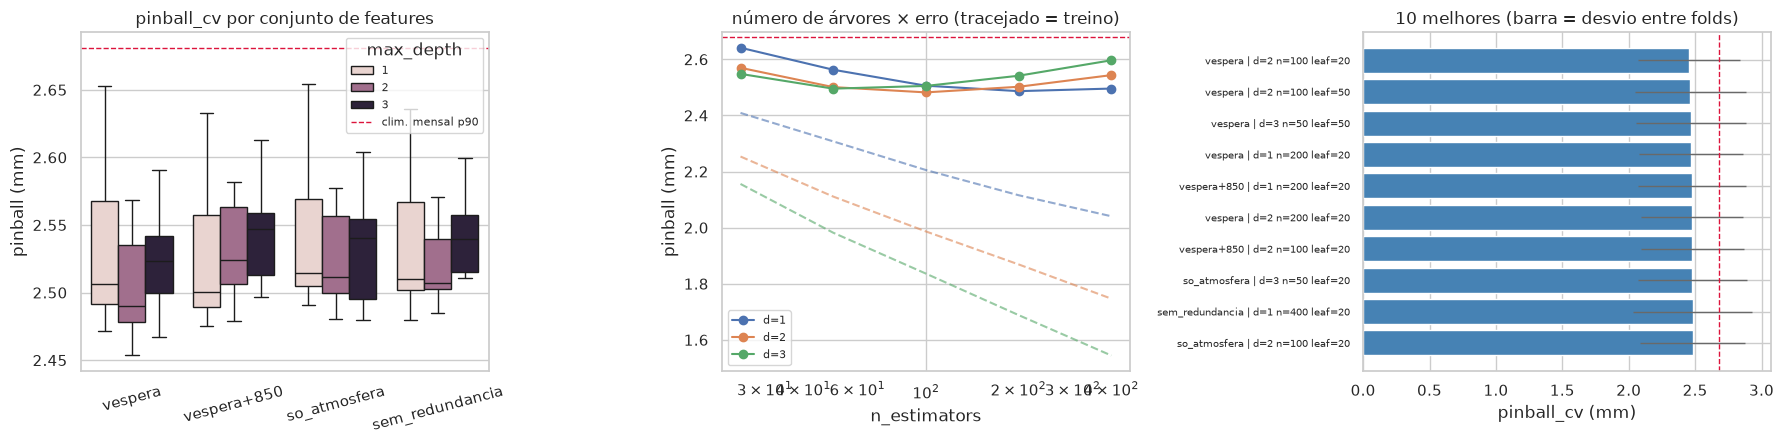

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

sns.boxplot(data=res.reset_index(), x="conjunto", y="pinball_cv", hue="d", ax=axes[0])
axes[0].axhline(clim_fold.mean(), color="crimson", ls="--", lw=1, label="clim. mensal p90")
axes[0].set(title="pinball_cv por conjunto de features", xlabel="", ylabel="pinball (mm)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(fontsize=8, title="max_depth")

med = res.groupby(["d", "n"])[["pinball_cv", "pinball_treino"]].mean().reset_index()
for d, g in med.groupby("d"):
    linha, = axes[1].plot(g.n, g.pinball_cv, "-o", label=f"d={d}")
    axes[1].plot(g.n, g.pinball_treino, "--", alpha=.6, color=linha.get_color())
axes[1].axhline(clim_fold.mean(), color="crimson", ls="--", lw=1)
axes[1].set(title="número de árvores × erro (tracejado = treino)", xlabel="n_estimators",
            ylabel="pinball (mm)", xscale="log")
axes[1].legend(fontsize=8)

top = res.nsmallest(10, "pinball_cv").iloc[::-1]
axes[2].barh(range(len(top)), top.pinball_cv, xerr=top.pinball_std, color="steelblue",
             error_kw={"lw": 1, "ecolor": "dimgray"})
axes[2].axvline(clim_fold.mean(), color="crimson", ls="--", lw=1)
axes[2].set_yticks(range(len(top)))
axes[2].set_yticklabels(top.index, fontsize=7)
axes[2].set(title="10 melhores (barra = desvio entre folds)", xlabel="pinball_cv (mm)")

plt.tight_layout()
salvar("cv_modelos")
plt.show()

#### Teste pareado por fold

Diagnóstico, não seleção: a variância entre folds é comum a todos os modelos, então a comparação é sobre as diferenças por fold.
A climatologia entra na mesma conta, fold a fold.

In [22]:
ff = pd.DataFrame(porfold).T
ff.columns = [f"fold{i+1}" for i in range(len(folds))]
print("pinball médio por fold:", ff.mean(axis=0).round(3).to_dict())
print(f"desvio entre folds: {ff.mean(axis=0).std(ddof=1):.3f} | "
      f"entre modelos: {res.pinball_cv.std(ddof=1):.3f} mm")

argmin = res.pinball_cv.idxmin()
dif = ff.sub(ff.loc[argmin], axis=1)
se = dif.std(axis=1, ddof=1) / np.sqrt(len(folds))
par = pd.DataFrame({"dif_media": dif.mean(axis=1), "SE_pareado": se,
                    "t": (dif.mean(axis=1) / se).where(se > 0, 0.0)}).join(res[["pinball_cv", "n_feats"]])

se_marg = res.loc[argmin, "pinball_std"] / np.sqrt(len(folds))
print(f"\nSE marginal: {se_marg:.3f} mm -> "
      f"{int((res.pinball_cv <= res.pinball_cv.min() + se_marg).sum())} de {len(res)} elegíveis")
print(f"SE pareado (mediano): {par.SE_pareado[par.SE_pareado > 0].median():.3f} mm")
print(f"indistinguíveis do melhor (|t| < 2): {int((par.t.abs() < 2).sum())} de {len(par)}")

d_clim = clim_fold - ff.loc[argmin].to_numpy()
se_clim = d_clim.std(ddof=1) / np.sqrt(len(folds))
print(f"\nclimatologia menos o melhor: {d_clim.mean():+.3f} ± {se_clim:.3f} mm, t = {d_clim.mean() / se_clim:+.2f}, "
      f"o melhor vence em {int((d_clim > 0).sum())} de {len(folds)} folds")

pinball médio por fold: {'fold1': 3.367, 'fold2': 2.359, 'fold3': 2.323, 'fold4': 2.23, 'fold5': 2.38}
desvio entre folds: 0.471 | entre modelos: 0.046 mm

SE marginal: 0.173 mm -> 113 de 120 elegíveis
SE pareado (mediano): 0.026 mm
indistinguíveis do melhor (|t| < 2): 37 de 120

climatologia menos o melhor: +0.228 ± 0.065 mm, t = +3.51, o melhor vence em 5 de 5 folds


#### Treino e teste

In [23]:
melhor = res.pinball_cv.idxmin()      # selecionado na CV
cols, hp = config[melhor]
print("selecionado:", melhor)
print(res.loc[melhor, ["pinball_cv", "pinball_std", "skill_cv_%", "cobertura_cv"]].astype(float).round(3).to_dict(), "\n")

final = modelo(**hp).fit(dev[cols], dev.tp_mm)
p_fin = final.predict(teste[cols])

ROTULO = f"BOOSTING p90 | {melhor}"
preds = {ROTULO: p_fin, **baselines(dev, teste)}
fin = pd.DataFrame([{"modelo": n, "pinball": pin(y_te, p), "cobertura": cobertura(y_te, p)}
                    for n, p in preds.items()]).set_index("modelo").sort_values("pinball")
fin["skill_vs_clim_%"] = 100 * (1 - fin.pinball / fin.loc["climatologia mensal p90", "pinball"])
print(fin.round(3).to_string())

selecionado: vespera | d=2 n=100 leaf=20
{'pinball_cv': 2.453, 'pinball_std': 0.387, 'skill_cv_%': 8.492, 'cobertura_cv': 0.889} 



                                            pinball  cobertura  skill_vs_clim_%
modelo                                                                         
BOOSTING p90 | vespera | d=2 n=100 leaf=20    2.407      0.905            3.195
p90 constante (dev)                           2.486      0.896            0.004
climatologia mensal p90                       2.486      0.911            0.000


salvo: teste_final.png


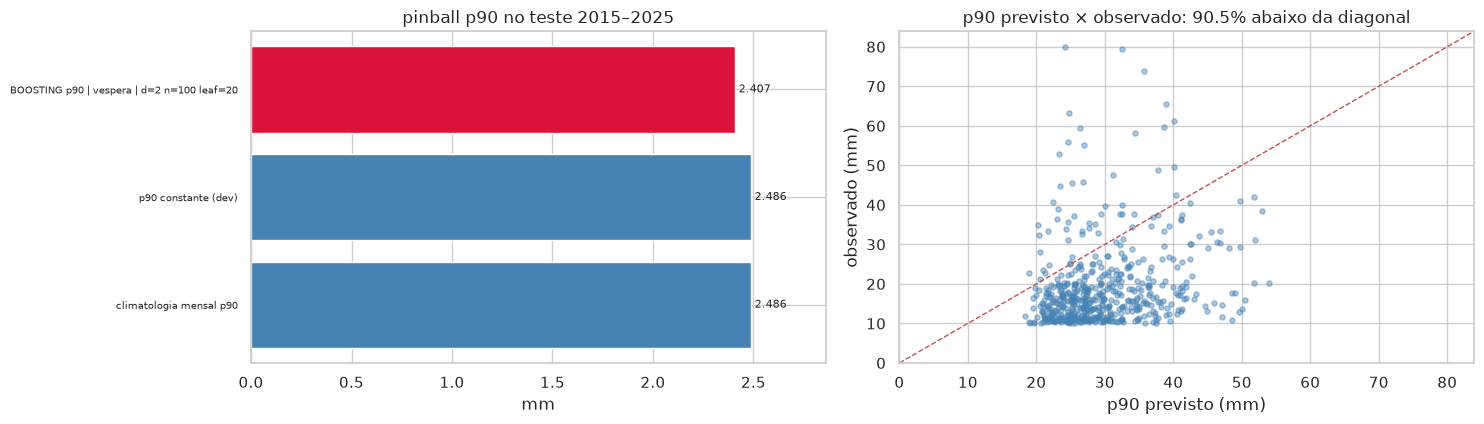

previsões: 18.3 a 54.0 mm | observado: 10.0 a 79.9 mm


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))

d = fin.sort_values("pinball")
axes[0].barh(range(len(d)), d.pinball, color=["crimson" if i == ROTULO else "steelblue" for i in d.index])
axes[0].set_yticks(range(len(d)))
axes[0].set_yticklabels(d.index, fontsize=7)
axes[0].invert_yaxis()
axes[0].set(title=f"pinball p90 no teste {teste.ano.min()}–{teste.ano.max()}", xlabel="mm")
axes[0].set_xlim(0, d.pinball.max() * 1.15)
for i, v in enumerate(d.pinball):
    axes[0].text(v, i, f" {v:.3f}", va="center", fontsize=8)

lim = [0, y_te.max() * 1.05]
axes[1].scatter(p_fin, y_te, s=14, alpha=.45, color="steelblue")
axes[1].plot(lim, lim, "r--", lw=1)
axes[1].set(title=f"p90 previsto × observado: {100 * cobertura(y_te, p_fin):.1f}% abaixo da diagonal",
            xlabel="p90 previsto (mm)", ylabel="observado (mm)", xlim=lim, ylim=lim)

plt.tight_layout()
salvar("teste_final")
plt.show()

print(f"previsões: {p_fin.min():.1f} a {p_fin.max():.1f} mm | observado: {y_te.min():.1f} a {y_te.max():.1f} mm")

#### Por ano e por faixa de previsão

O total do teste pode esconder um ganho que vem de poucos anos. E a cobertura de 0,90 no total pode esconder um modelo largo
nos dias calmos e curto nos dias de risco: a cobertura precisa ficar perto de 0,90 em cada faixa de previsão.

In [25]:
p_clim = baselines(dev, teste)["climatologia mensal p90"]
q_dia = lambda y, p: np.maximum(Q * (y - p), (Q - 1) * (y - p))     # pinball de cada dia
t = teste.assign(l_mod=q_dia(y_te, p_fin), l_clim=q_dia(y_te, p_clim))

por_ano = t.groupby("ano").agg(n=("tp_mm", "size"), max_mm=("tp_mm", "max"),
                               pinball_modelo=("l_mod", "mean"), pinball_clim=("l_clim", "mean"))
por_ano["skill_%"] = 100 * (1 - por_ano.pinball_modelo / por_ano.pinball_clim)
print(por_ano.round(2).to_string())
print(f"\nanos em que o modelo vence: {int((por_ano['skill_%'] > 0).sum())} de {len(por_ano)}")

       n     max_mm  pinball_modelo  pinball_clim  skill_%
ano                                                       
2015  65  79.519997            3.39          3.08    -9.90
2016  48  52.900002            2.04          2.17     5.96
2017  44  39.860001            1.57          1.52    -3.53
2018  36  34.220001            1.32          1.57    16.21
2019  40  61.259998            1.99          2.09     4.63
2020  37  59.330002            3.20          2.72   -17.45
2021  46  73.879997            2.22          2.59    14.30
2022  66  37.060001            1.62          1.70     4.85
2023  59  65.589996            1.95          2.41    19.16
2024  55  79.910004            3.07          3.62    15.14
2025  42  63.220001            4.02          3.63   -10.89

anos em que o modelo vence: 7 de 11


           n  p90_previsto_medio  p90_observado  cobertura
baixa  180.0              23.057         25.366      0.861
média  179.0              28.198         24.922      0.933
alta   179.0              37.970         37.369      0.922
salvo: calibracao.png


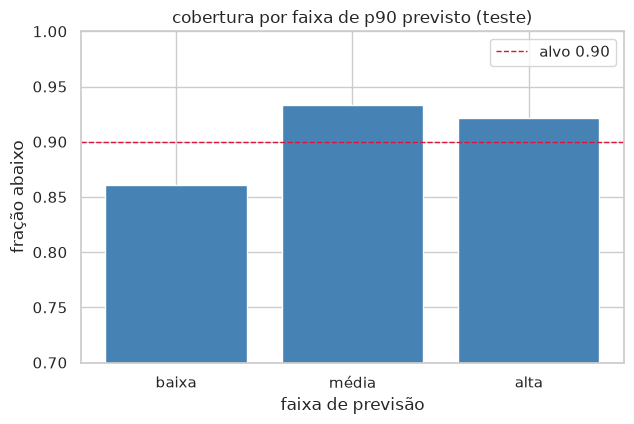

In [26]:
faixa = pd.qcut(p_fin, 3, labels=["baixa", "média", "alta"])
calib = pd.DataFrame({"obs": y_te.to_numpy(), "prev": p_fin}).groupby(faixa, observed=True).apply(
    lambda g: pd.Series({"n": len(g), "p90_previsto_medio": g.prev.mean(),
                         "p90_observado": g.obs.quantile(Q), "cobertura": cobertura(g.obs, g.prev)}))
print(calib.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.bar(calib.index.astype(str), calib.cobertura, color="steelblue")
ax.axhline(Q, color="crimson", ls="--", lw=1, label=f"alvo {Q:.2f}")
ax.set(title="cobertura por faixa de p90 previsto (teste)", xlabel="faixa de previsão", ylabel="fração abaixo",
       ylim=(0.7, 1))
ax.legend()
plt.tight_layout()
salvar("calibracao")
plt.show()

#### Importância das Features

salvo: importancia.png


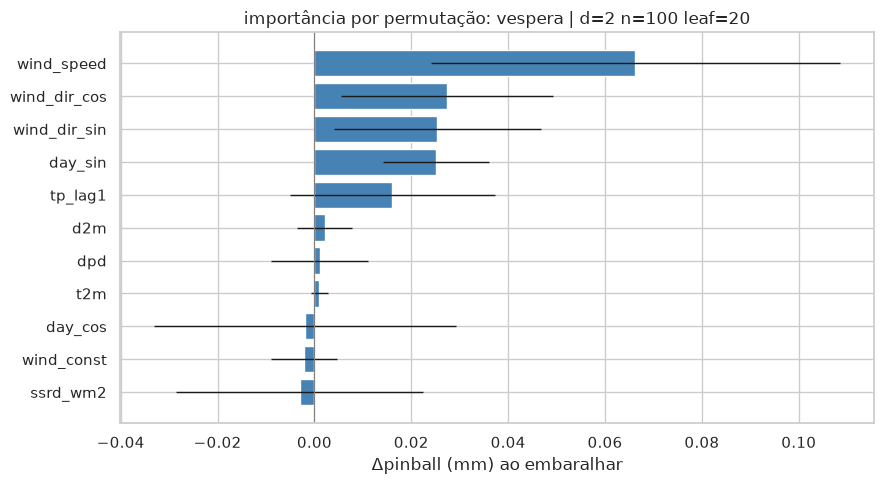

               media     std
wind_speed    0.0662  0.0422
wind_dir_cos  0.0274  0.0219
wind_dir_sin  0.0254  0.0213
day_sin       0.0250  0.0109
tp_lag1       0.0160  0.0211
d2m           0.0021  0.0056
dpd           0.0011  0.0100
t2m           0.0010  0.0018
day_cos      -0.0019  0.0311
wind_const   -0.0023  0.0068
ssrd_wm2     -0.0031  0.0254

nunca entram em split: []
indistinguível de zero (média < 2×std): ['wind_speed', 'wind_dir_cos', 'wind_dir_sin', 'tp_lag1', 'd2m', 'dpd', 't2m', 'day_cos', 'wind_const', 'ssrd_wm2']


In [27]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

pi = permutation_importance(final, teste[cols], y_te, n_repeats=20, random_state=SEED,
                            scoring=make_scorer(pin, greater_is_better=False))
imp = pd.DataFrame({"media": pi.importances_mean, "std": pi.importances_std},
                   index=cols).sort_values("media", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index[::-1], imp.media[::-1], xerr=imp["std"][::-1],
        color="steelblue", error_kw={"lw": 1})
ax.axvline(0, color="gray", lw=.8)
ax.set(title=f"importância por permutação: {melhor}", xlabel="Δpinball (mm) ao embaralhar")
plt.tight_layout()
salvar("importancia")
plt.show()

print(imp.round(4))
print("\nnunca entram em split:", [c for c, v in zip(cols, final.feature_importances_) if v == 0])
print("indistinguível de zero (média < 2×std):", list(imp[imp.media < 2 * imp["std"]].index))

#### Reprodutibilidade

In [28]:
a = modelo(**hp).fit(dev[cols], dev.tp_mm).predict(teste[cols])
b = modelo(**hp).fit(dev[cols], dev.tp_mm).predict(teste[cols])
print("mesma semente, duas rodadas idênticas:", np.array_equal(a, b))

# com subsample < 1 a semente muda as árvores, então a variação entre sementes é real
sementes = [pin(y_te, GradientBoostingRegressor(loss="quantile", alpha=Q, random_state=s, **hp)
                .fit(dev[cols], dev.tp_mm).predict(teste[cols])) for s in range(5)]
print(f"pinball no teste em 5 sementes: {np.round(sementes, 4).tolist()} (desvio {np.std(sementes):.4f})")
print(f"desvio entre folds: {res.loc[melhor, 'pinball_std']:.3f} | "
      f"diferença entre os 5 melhores do CV: {res.pinball_cv.nsmallest(5).max() - res.pinball_cv.min():.3f} mm")

mesma semente, duas rodadas idênticas: True


pinball no teste em 5 sementes: [2.3963, 2.3942, 2.369, 2.3939, 2.4049] (desvio 0.0120)
desvio entre folds: 0.387 | diferença entre os 5 melhores do CV: 0.022 mm


In [29]:
import joblib, sklearn

MODELDIR = Path("modelos")
MODELDIR.mkdir(exist_ok=True)
caminho = MODELDIR / "modelo_p90.joblib"

joblib.dump({"modelo": final, "features": list(cols), "limiar": LIMIAR, "semente": SEED,
             "hiperparametros": hp, "quantil": Q, "perda": "pinball", "sklearn": sklearn.__version__,
             "treino_ate": ANO_CORTE, "alvo": "tp_mm"}, caminho)

pac = joblib.load(caminho)
p_rec = pac["modelo"].predict(teste[pac["features"]])
print(f"salvo em {caminho} | features na ordem: {pac['features'] == list(cols)} | "
      f"previsão idêntica: {np.array_equal(p_fin, p_rec)} | sklearn {pac['sklearn']}")

salvo em modelos/modelo_p90.joblib | features na ordem: True | previsão idêntica: True | sklearn 1.9.0


**Decisões**

| | decisão | por quê |
|---|---|---|
| Limiar | 10 mm/dia (`R10mm`, ETCCDI) | 2.395 dias (1.857 dev / 538 teste), 65% da chuva. Usar "dia de chuva forte", não "extremo": o extremo para Curitiba é o p99, 48,6 mm (Goudard & Mendonça, 2020) |
| Base do percentil | dias chuvosos (≥ 1 mm) | como no ETCCDI. O p99 sobre dias chuvosos (46,6 mm) reproduz os 48,6 mm publicados; sobre todos os dias daria 36,0 mm |
| Agrupamento | manter todos os dias ≥ 10 mm | autocorrelação residual na subamostra 0,065; declusterizar custaria 33% dos dados e mudaria o alvo para "pico do episódio". Declarar θ junto dos intervalos |
| Acumulados | faixas disjuntas | `tp_sum7/30/90` são aninhados e colineares por construção (Aas et al., 2021) |
| Folds | por data | `test_size=365*4` conta linhas, não anos |
| Climatologia | média mensal, refeita na subamostra | 12 parâmetros; a da série completa aplicada ao teste filtrado dá RMSE 17,7 |
| Modelo | gradient boosting quantílico (p90), árvores rasas | a média condicional não tem sinal: nenhuma árvore de regressão venceu a climatologia mensal no teste. O p90 tem, porque as features movem mais a cauda do que a média. Uma árvore quantílica única perdia no teste (-4,6%) porque o p90 de cada folha sai de poucos dias; o boosting reduz essa variância |
| Métrica | perda pinball no quantil 0,9, skill contra o p90 mensal e cobertura | o mínimo da pinball é o p90 verdadeiro, como o do erro quadrático é a média. A cobertura mostra se o modelo erra para baixo |
| Outras cidades | não | sem tendência significativa nos índices de precipitação do Paraná (Silva et al., 2015) |

**Seleção de features** (feita com a árvore de regressão, versão anterior). 40 → 29 por redundância cega ao alvo (`|r| > 0,85`): saem `cape_mean`, `tcwv_max`, `wind850_speed_max`, `q850_mean`, `t2m_min`, `t2m_max`, `d2m_lag3`, `wind_max` e as três faixas (autocorrelação 0,92–0,995, não distinguem dias vizinhos). 29 → 20 sem as 9 de importância zero em todos os folds (na CV, as 29 e as 20 deram o mesmo RMSE_cv, 11,583 mm, por isso o conjunto de 29 não é mais avaliado). Apertar para `|r| > 0,60` piora o CV (11,656 × 11,583), e selecionar por correlação com o alvo piorou o teste.

**Resultado.** Condicionar em dia forte destrói o sinal marginal: `tp_lag1` cai de 0,54 para 0,08, `ssrd_wm2` vira a mais forte e `d2m`/`t2m` trocam de sinal. Com a árvore de regressão (versão anterior, RMSE), nenhum modelo da grade era distinguível do melhor no teste pareado, nem a árvore de uma folha. Trocando o alvo para o p90, o boosting (`vespera`, profundidade 2, 100 árvores, folha 20) vence a climatologia nos 5 folds (t = +3,5) e no teste 2015–2025: pinball 2,407 contra 2,486 (+3,2%), cobertura 0,905. O ganho vem em 7 de 11 anos e se repete em todas as décadas quando cada uma fica de fora (+5% a +11%). Ponto fraco: nos dias de p90 previsto mais baixo a cobertura cai para 0,86, então ali o modelo ainda erra para baixo. Nenhuma feature isolada tem importância por permutação distinguível de zero; o ganho vem da combinação.

**Em aberto.** Explicabilidade local (SHAP); o ERA5-Land tem cerca de metade dos dias extremos do pluviômetro (78 acima de 47,3 mm em 1980–2025 contra 132 acima de 48,6 mm em Goudard & Mendonça); corrigir o atv2 para a climatologia mensal (7,243 mm, ganho de 6,0% em vez de 7,4%).

**Referências.** ETCCDI ([definições](https://etccdi.pacificclimate.org/docs/ETCCDMIndicesComparison1.pdf)) · Goudard & Mendonça (2020), *IdeAs* 15, [doi:10.4000/ideas.8082](https://doi.org/10.4000/ideas.8082) · Silva et al. (2015), *RBMet* 30(2) ([SciELO](http://www.scielo.br/j/rbmet/a/G5w6XK4sLCFkJYNs8SFjgcn/?lang=pt)) · Rudin (2019), *Nat. Mach. Intell.* 1, [doi:10.1038/s42256-019-0048-x](https://doi.org/10.1038/s42256-019-0048-x) · Aas et al. (2021), *Artif. Intell.* 298, [doi:10.1016/j.artint.2021.103502](https://doi.org/10.1016/j.artint.2021.103502) · Ferro & Segers (2003), *JRSS-B* 65(2) ([PDF](https://mistis.inrialpes.fr/docs/EXTREMES/Ferro2003.pdf))